# Step 3: Split-wise Model Performance Evaluation on HC3 Dataset

This notebook evaluates the trained RNN model on each HC3 dataset split separately:
- **Finance** - Financial domain Q&A
- **Medicine** - Medical domain Q&A  
- **Open QA** - General open-domain questions
- **Reddit ELI5** - Reddit Explain Like I'm 5
- **Wikipedia** - Wikipedia articles

**Features:**
- Split-wise performance metrics (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
- Individual confusion matrices for each split
- Comparative visualizations across splits
- Detailed performance analysis to identify domain-specific patterns

**Required:** Trained model from `2b_train_with_embeddings_colab.ipynb` and HC3 embeddings

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!


## 2. Setup and Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report, matthews_corrcoef, cohen_kappa_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import json
import pickle
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


## 3. Configuration

In [3]:
# ==================== IMPORTANT: SET THESE PATHS ====================
# Path to your training results directory (from 2b_train_with_embeddings_colab.ipynb)
# Example: "/content/drive/MyDrive/RNN_Training_Results/20231203_154530"
TRAINING_RESULTS_DIR = "/content/drive/MyDrive/RNN_Training_Results/20251204_051426"

# Path to your HC3 embeddings directory (from 2a_create_hc3_embeddings_colab.ipynb)
# Example: "/content/drive/MyDrive/hc3_embeddings/20231203_153045"
EMBEDDINGS_DIR = "/content/drive/MyDrive/hc3_embeddings/20251204_173530"

# ==================================================================

# Output directory for evaluation results
EVALUATION_OUTPUT_DIR = os.path.join(
    "/content/drive/MyDrive/HC3_Model_Evaluation",
    datetime.now().strftime("%Y%m%d_%H%M%S")
)
os.makedirs(EVALUATION_OUTPUT_DIR, exist_ok=True)

print(f"Training results directory: {TRAINING_RESULTS_DIR}")
print(f"HC3 Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Evaluation results will be saved to: {EVALUATION_OUTPUT_DIR}")

Training results directory: /content/drive/MyDrive/RNN_Training_Results/20251204_051426
HC3 Embeddings directory: /content/drive/MyDrive/hc3_embeddings/20251204_173530
Evaluation results will be saved to: /content/drive/MyDrive/HC3_Model_Evaluation/20251205_060556


## 4. Device Setup

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✓ Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


✓ Using device: cuda
  GPU: NVIDIA L4
  Memory: 23.80 GB


## 5. Load Model Architecture

In [5]:
class SequenceArtifactDetector(nn.Module):
    """
    Bidirectional LSTM for detecting AI-generated text based on sequential patterns.
    Processes variable-length document sequences.
    """

    def __init__(self, embedding_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super(SequenceArtifactDetector, self).__init__()

        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        lstm_output_dim = hidden_dim * 2  # *2 for bidirectional

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_output_dim // 2, 1),
            nn.Softmax(dim=1)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if 'lstm' in name:
                    nn.init.xavier_uniform_(param)
                elif len(param.shape) >= 2:
                    nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, x, lengths):
        """
        Args:
            x: (batch_size, max_seq_len, embedding_dim)
            lengths: (batch_size,) actual lengths of sequences
        """
        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # LSTM forward
        packed_out, (hidden, cell) = self.lstm(packed)

        # Unpack
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        # Attention mechanism
        attention_weights = self.attention(lstm_out)
        attended = torch.sum(lstm_out * attention_weights, dim=1)

        # Classification
        output = self.classifier(attended)
        return output

print("✓ Model architecture loaded (Bidirectional LSTM with Attention)")

✓ Model architecture loaded (Bidirectional LSTM with Attention)


## 6. Load Dataset Classes

In [6]:
class SequenceDataset(Dataset):
    """Dataset that returns variable-length sequences."""

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    """Collate function to pad variable-length sequences."""
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    return padded_sequences, labels, lengths

print("✓ Dataset classes loaded")

✓ Dataset classes loaded


## 7. Load Trained Model

In [7]:
# Load model checkpoint
model_path = os.path.join(TRAINING_RESULTS_DIR, "best_model.pth")
config_path = os.path.join(TRAINING_RESULTS_DIR, "full_config.json")

print(f"Loading model from: {model_path}")

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model not found at: {model_path}\n"
        f"Please run '2b_train_with_embeddings_colab.ipynb' first and update TRAINING_RESULTS_DIR."
    )

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device, weights_only=False)

# Load configuration
with open(config_path, 'r') as f:
    config = json.load(f)

# IMPORTANT: Use actual embedding dimension from data (original + injected)
# The checkpoint may have wrong embedding_dim saved
actual_embedding_dim = 4096  # 2048 (original) + 2048 (injected)

# Initialize model with correct embedding dimension
model = SequenceArtifactDetector(
    embedding_dim=actual_embedding_dim,  # Use actual dimension
    hidden_dim=checkpoint.get('hidden_dim', 128),
    num_layers=checkpoint.get('num_layers', 2),
    dropout=checkpoint['dropout']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded successfully")
print(f"  Actual embedding dim: {actual_embedding_dim}")
print(f"  Checkpoint embedding dim: {checkpoint.get('embedding_dim', 'N/A')}")
print(f"  Hidden dim: {checkpoint.get('hidden_dim', 128)}")
print(f"  Num layers: {checkpoint.get('num_layers', 2)}")
print(f"  Dropout: {checkpoint['dropout']}")
print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
print(f"  Trained epoch: {checkpoint['epoch']+1}")

Loading model from: /content/drive/MyDrive/RNN_Training_Results/20251204_051426/best_model.pth
✓ Model loaded successfully
  Actual embedding dim: 4096
  Checkpoint embedding dim: 4096
  Hidden dim: 128
  Num layers: 2
  Dropout: 0.4
  Validation accuracy: 98.82%
  Trained epoch: 35


## 8. Load Test Data

In [8]:
# Load embeddings
embeddings_file = os.path.join(EMBEDDINGS_DIR, "embeddings.pkl")

print(f"Loading HC3 embeddings from: {embeddings_file}")

with open(embeddings_file, 'rb') as f:
    embeddings_data = pickle.load(f)

# Load metadata to get split information
metadata_file = os.path.join(EMBEDDINGS_DIR, "embeddings_metadata.json")
with open(metadata_file, 'r') as f:
    metadata = json.load(f)

print(f"✓ Embeddings loaded")
print(f"  Available splits: {list(embeddings_data.keys())}")

# Store all split data
split_data = {}
for split_name, split_dict in embeddings_data.items():
    orig_seqs = split_dict['original_sequences']
    inj_seqs = split_dict['injected_sequences']

    # Concatenate original + injected embeddings
    sequences = [torch.cat([o, i], dim=1) for o, i in zip(orig_seqs, inj_seqs)]
    labels = split_dict['labels']

    split_data[split_name] = {
        'sequences': sequences,
        'labels': labels
    }

    print(f"  {split_name}: {len(sequences)} samples")

print(f"  Embedding dimension: {split_data[list(split_data.keys())[0]]['sequences'][0].shape[1]}")

Loading HC3 embeddings from: /content/drive/MyDrive/hc3_embeddings/20251204_173530/embeddings.pkl
✓ Embeddings loaded
  Available splits: ['train', 'val', 'test']
  train: 988 samples
  val: 330 samples
  test: 330 samples
  Embedding dimension: 4096


## 9. Evaluate Model on Each Split

In [9]:
def evaluate_split(split_name, sequences, labels):
    """Evaluate model on a single split and return metrics."""
    # Create dataset and loader
    dataset = SequenceDataset(sequences, labels)
    loader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

    # Generate predictions
    all_probs = []
    all_preds = []
    all_true = []

    model.eval()
    with torch.no_grad():
        for batch_X, batch_y, lengths in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            lengths = lengths.to(device)

            outputs = model(batch_X, lengths)
            predictions = (outputs > 0.5).float()

            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            all_true.extend(batch_y.cpu().numpy())

    # Convert to numpy arrays
    all_probs = np.array(all_probs).flatten()
    all_preds = np.array(all_preds).flatten()
    all_true = np.array(all_true).flatten()

    # Calculate metrics
    accuracy = accuracy_score(all_true, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true, all_preds, average='binary', zero_division=0
    )

    cm = confusion_matrix(all_true, all_preds)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    mcc = matthews_corrcoef(all_true, all_preds)
    kappa = cohen_kappa_score(all_true, all_preds)

    fpr_roc, tpr_roc, _ = roc_curve(all_true, all_probs)
    roc_auc = auc(fpr_roc, tpr_roc)
    pr_auc = average_precision_score(all_true, all_probs)

    return {
        'split_name': split_name,
        'predictions': all_preds,
        'probabilities': all_probs,
        'true_labels': all_true,
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1': f1,
            'npv': npv,
            'fpr': fpr,
            'fnr': fnr,
            'mcc': mcc,
            'kappa': kappa,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
        },
        'confusion_matrix': {
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp)
        },
        'roc_curve': {
            'fpr': fpr_roc,
            'tpr': tpr_roc
        }
    }

# Evaluate each split
print("\n" + "="*70)
print("Evaluating model on each HC3 split")
print("="*70)

split_results = {}
for split_name in sorted(split_data.keys()):
    print(f"\nEvaluating {split_name}...")
    sequences = split_data[split_name]['sequences']
    labels = split_data[split_name]['labels']

    result = evaluate_split(split_name, sequences, labels)
    split_results[split_name] = result

    print(f"  ✓ {split_name}: Acc={result['metrics']['accuracy']*100:.2f}%, "
          f"F1={result['metrics']['f1']*100:.2f}%, "
          f"Samples={len(result['true_labels'])}")

print("\n" + "="*70)
print("✓ All splits evaluated")


Evaluating model on each HC3 split

Evaluating test...
  ✓ test: Acc=78.48%, F1=78.02%, Samples=330

Evaluating train...
  ✓ train: Acc=77.94%, F1=77.39%, Samples=988

Evaluating val...
  ✓ val: Acc=75.76%, F1=76.74%, Samples=330

✓ All splits evaluated


## 10. Display Split-wise Performance Summary

In [10]:
# Create summary table
summary_data = []
for split_name in sorted(split_results.keys()):
    result = split_results[split_name]
    metrics = result['metrics']
    cm = result['confusion_matrix']

    summary_data.append({
        'Split': split_name,
        'Samples': len(result['true_labels']),
        'Accuracy': f"{metrics['accuracy']*100:.2f}%",
        'Precision': f"{metrics['precision']*100:.2f}%",
        'Recall': f"{metrics['recall']*100:.2f}%",
        'F1-Score': f"{metrics['f1']*100:.2f}%",
        'Specificity': f"{metrics['specificity']*100:.2f}%",
        'ROC-AUC': f"{metrics['roc_auc']:.4f}",
        'PR-AUC': f"{metrics['pr_auc']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("SPLIT-WISE PERFORMANCE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

# Calculate average metrics
avg_accuracy = np.mean([r['metrics']['accuracy'] for r in split_results.values()])
avg_f1 = np.mean([r['metrics']['f1'] for r in split_results.values()])
avg_roc_auc = np.mean([r['metrics']['roc_auc'] for r in split_results.values()])

print(f"\nAverage across all splits:")
print(f"  Accuracy: {avg_accuracy*100:.2f}%")
print(f"  F1-Score: {avg_f1*100:.2f}%")
print(f"  ROC-AUC:  {avg_roc_auc:.4f}")
print("="*100)


SPLIT-WISE PERFORMANCE SUMMARY
Split  Samples Accuracy Precision Recall F1-Score Specificity ROC-AUC PR-AUC
 test      330   78.48%    96.92% 65.28%   78.02%      97.08%  0.9513 0.9600
train      988   77.94%    96.13% 64.76%   77.39%      96.36%  0.9357 0.9416
  val      330   75.76%    96.35% 63.77%   76.74%      95.93%  0.9276 0.9538

Average across all splits:
  Accuracy: 77.39%
  F1-Score: 77.38%
  ROC-AUC:  0.9382


## 11. Visualize Split-wise Performance

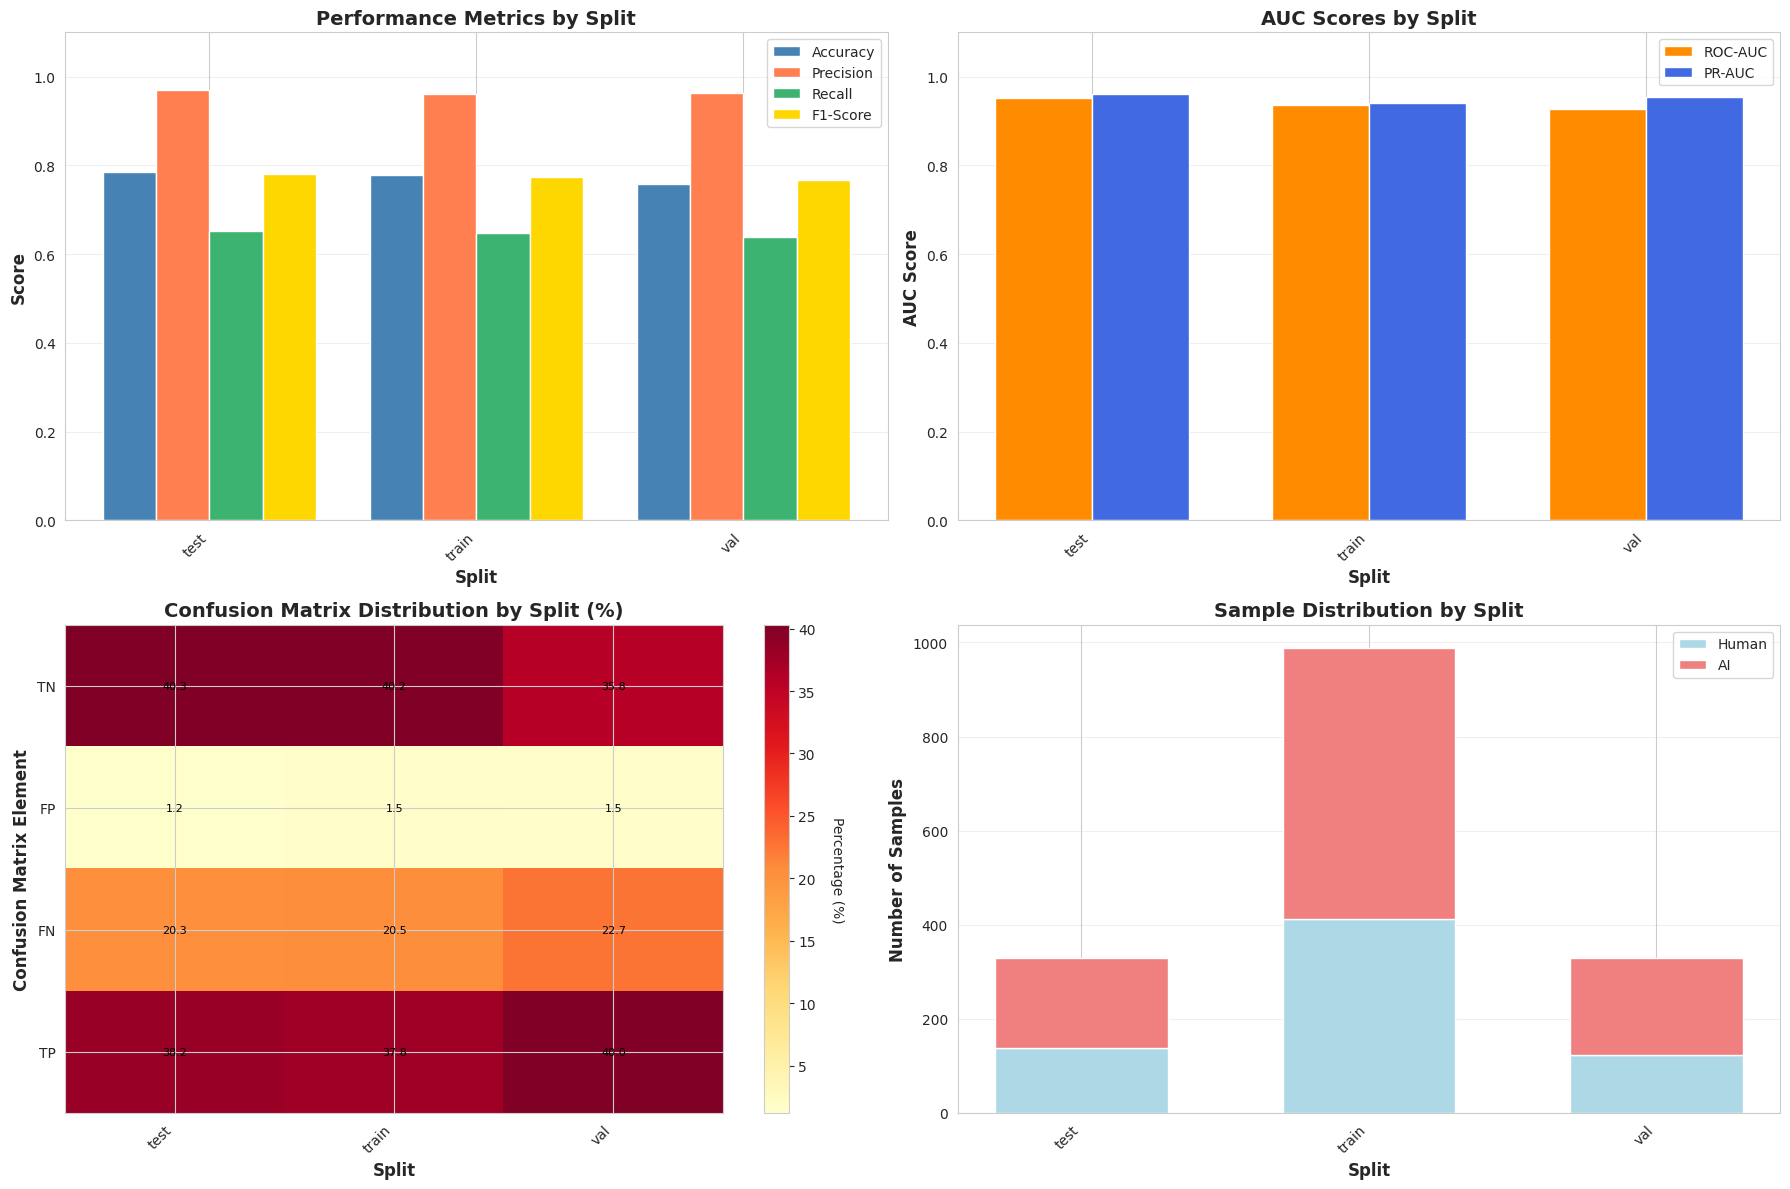

✓ Split-wise performance visualization saved


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

split_names = sorted(split_results.keys())
colors = plt.cm.Set3(np.linspace(0, 1, len(split_names)))

# 1. Accuracy, Precision, Recall, F1 comparison
ax = axes[0, 0]
x = np.arange(len(split_names))
width = 0.2

accuracies = [split_results[s]['metrics']['accuracy'] for s in split_names]
precisions = [split_results[s]['metrics']['precision'] for s in split_names]
recalls = [split_results[s]['metrics']['recall'] for s in split_names]
f1s = [split_results[s]['metrics']['f1'] for s in split_names]

ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, precisions, width, label='Precision', color='coral')
ax.bar(x + 0.5*width, recalls, width, label='Recall', color='mediumseagreen')
ax.bar(x + 1.5*width, f1s, width, label='F1-Score', color='gold')

ax.set_xlabel('Split', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics by Split', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# 2. ROC-AUC and PR-AUC comparison
ax = axes[0, 1]
x = np.arange(len(split_names))
width = 0.35

roc_aucs = [split_results[s]['metrics']['roc_auc'] for s in split_names]
pr_aucs = [split_results[s]['metrics']['pr_auc'] for s in split_names]

ax.bar(x - width/2, roc_aucs, width, label='ROC-AUC', color='darkorange')
ax.bar(x + width/2, pr_aucs, width, label='PR-AUC', color='royalblue')

ax.set_xlabel('Split', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
ax.set_title('AUC Scores by Split', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# 3. Confusion matrices heatmap
ax = axes[1, 0]
confusion_data = []
for split_name in split_names:
    cm = split_results[split_name]['confusion_matrix']
    # Normalize by total samples
    total = cm['tn'] + cm['fp'] + cm['fn'] + cm['tp']
    confusion_data.append([
        cm['tn']/total * 100,
        cm['fp']/total * 100,
        cm['fn']/total * 100,
        cm['tp']/total * 100
    ])

confusion_array = np.array(confusion_data)
im = ax.imshow(confusion_array.T, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(split_names)))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.set_yticklabels(['TN', 'FP', 'FN', 'TP'])
ax.set_xlabel('Split', fontsize=12, fontweight='bold')
ax.set_ylabel('Confusion Matrix Element', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix Distribution by Split (%)', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Percentage (%)', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(split_names)):
    for j in range(4):
        text = ax.text(i, j, f'{confusion_array[i, j]:.1f}',
                      ha="center", va="center", color="black", fontsize=8)

# 4. Sample distribution by split
ax = axes[1, 1]
x = np.arange(len(split_names))

human_counts = []
ai_counts = []
for split_name in split_names:
    true_labels = split_results[split_name]['true_labels']
    human_counts.append((true_labels == 0).sum())
    ai_counts.append((true_labels == 1).sum())

width = 0.6
ax.bar(x, human_counts, width, label='Human', color='lightblue')
ax.bar(x, ai_counts, width, bottom=human_counts, label='AI', color='lightcoral')

ax.set_xlabel('Split', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Sample Distribution by Split', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "split_wise_performance.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Split-wise performance visualization saved")

## 12. Individual Split Confusion Matrices

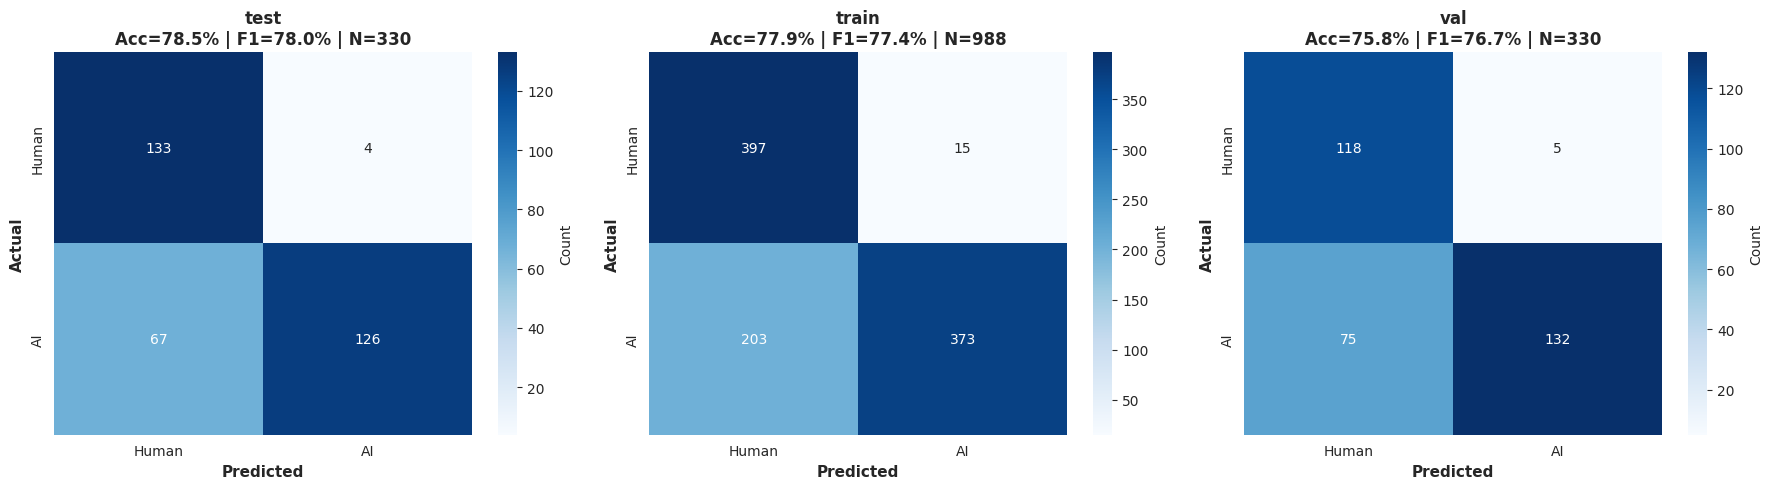

✓ Individual confusion matrices saved


In [12]:
# Create confusion matrices for each split
n_splits = len(split_names)
n_cols = min(3, n_splits)
n_rows = (n_splits + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_splits == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, split_name in enumerate(split_names):
    result = split_results[split_name]
    cm_dict = result['confusion_matrix']

    # Create confusion matrix array
    cm_array = np.array([
        [cm_dict['tn'], cm_dict['fp']],
        [cm_dict['fn'], cm_dict['tp']]
    ])

    # Plot
    ax = axes[idx]
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
                cbar_kws={'label': 'Count'})

    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')

    # Add metrics to title
    metrics = result['metrics']
    title = f"{split_name}\n"
    title += f"Acc={metrics['accuracy']*100:.1f}% | "
    title += f"F1={metrics['f1']*100:.1f}% | "
    title += f"N={len(result['true_labels'])}"
    ax.set_title(title, fontsize=12, fontweight='bold')

# Hide unused subplots
for idx in range(n_splits, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "split_confusion_matrices.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Individual confusion matrices saved")

## 13. ROC Curves by Split

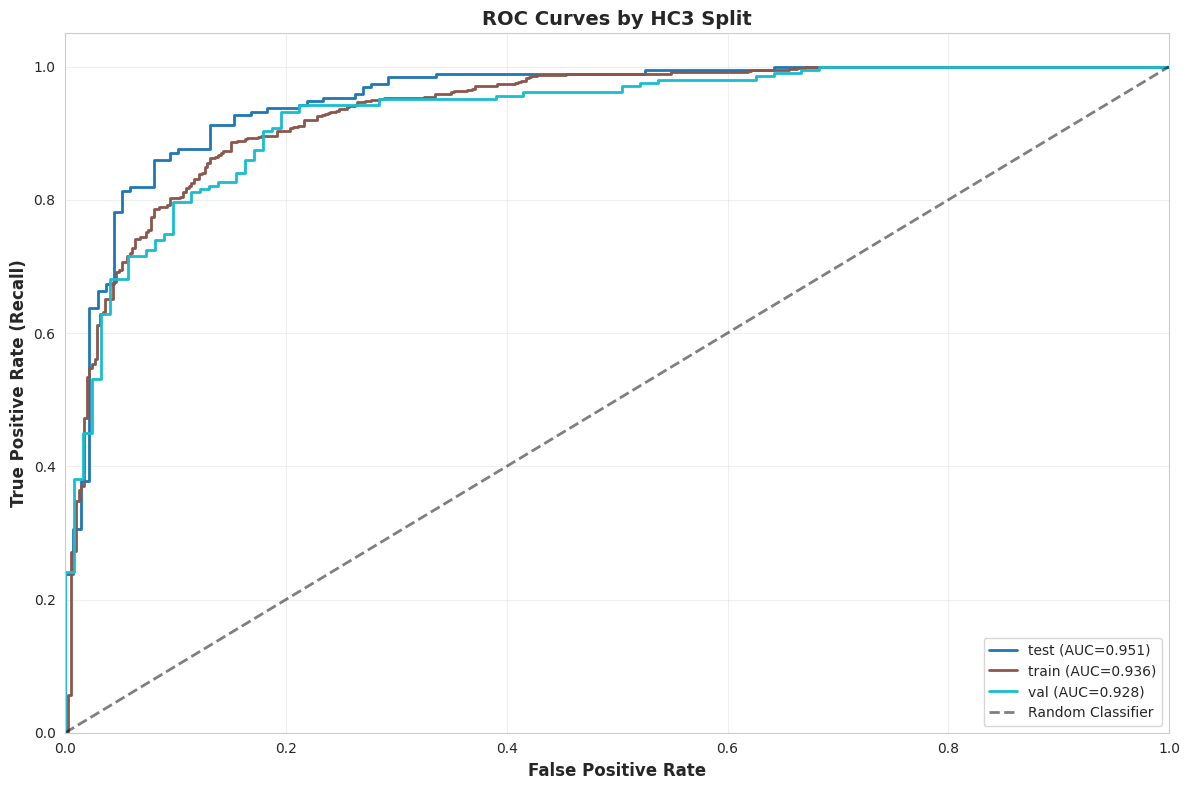

✓ ROC curves by split saved


In [13]:
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(split_names)))

for idx, split_name in enumerate(split_names):
    result = split_results[split_name]
    roc_curve_data = result['roc_curve']
    roc_auc = result['metrics']['roc_auc']

    plt.plot(roc_curve_data['fpr'], roc_curve_data['tpr'],
             color=colors[idx], lw=2,
             label=f'{split_name} (AUC={roc_auc:.3f})')

# Plot random classifier
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--',
         label='Random Classifier', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curves by HC3 Split', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVALUATION_OUTPUT_DIR, "split_roc_curves.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves by split saved")

## 14. Save Split-wise Results

In [14]:
# Prepare results for JSON export (exclude numpy arrays)
export_results = {
    'model_info': {
        'training_dir': TRAINING_RESULTS_DIR,
        'embeddings_dir': EMBEDDINGS_DIR,
        'model_architecture': 'Bidirectional LSTM with Attention',
        'embedding_dim': actual_embedding_dim,
        'hidden_dim': checkpoint.get('hidden_dim', 128),
        'num_layers': checkpoint.get('num_layers', 2),
        'dropout': checkpoint['dropout'],
        'trained_epoch': checkpoint['epoch'] + 1,
        'validation_accuracy': float(checkpoint['val_acc'])
    },
    'overall_statistics': {
        'total_splits': len(split_results),
        'total_samples': sum(len(r['true_labels']) for r in split_results.values()),
        'average_accuracy': float(avg_accuracy),
        'average_f1': float(avg_f1),
        'average_roc_auc': float(avg_roc_auc)
    },
    'split_results': {}
}

# Add each split's results
for split_name, result in split_results.items():
    export_results['split_results'][split_name] = {
        'num_samples': len(result['true_labels']),
        'num_human': int((result['true_labels'] == 0).sum()),
        'num_ai': int((result['true_labels'] == 1).sum()),
        'metrics': {k: float(v) for k, v in result['metrics'].items()},
        'confusion_matrix': result['confusion_matrix']
    }

# Save to JSON
with open(os.path.join(EVALUATION_OUTPUT_DIR, "split_wise_results.json"), "w") as f:
    json.dump(export_results, f, indent=2)

# Save summary table as CSV
summary_df.to_csv(os.path.join(EVALUATION_OUTPUT_DIR, "split_wise_summary.csv"), index=False)

print("\n✓ Split-wise results saved:")
print(f"  - split_wise_results.json")
print(f"  - split_wise_summary.csv")


✓ Split-wise results saved:
  - split_wise_results.json
  - split_wise_summary.csv


## 15. Final Summary

In [15]:
print("\n" + "="*100)
print("EVALUATION COMPLETE - SPLIT-WISE SUMMARY")
print("="*100)
print(f"\n✓ All results saved to Google Drive:")
print(f"  {EVALUATION_OUTPUT_DIR}\n")

print("Generated Files:")
print("  1. split_wise_results.json - Complete metrics for all splits in JSON")
print("  2. split_wise_summary.csv - Summary table in CSV format")
print("  3. split_wise_performance.png - Overall performance comparison")
print("  4. split_confusion_matrices.png - Individual confusion matrices")
print("  5. split_roc_curves.png - ROC curves for all splits\n")

print("="*100)
print("SPLIT-WISE RESULTS")
print("="*100)

for split_name in sorted(split_results.keys()):
    result = split_results[split_name]
    metrics = result['metrics']
    cm = result['confusion_matrix']
    n_samples = len(result['true_labels'])

    print(f"\n📊 {split_name.upper()}")
    print(f"{'─'*100}")
    print(f"  Samples: {n_samples} ({(result['true_labels']==0).sum()} Human, {(result['true_labels']==1).sum()} AI)")
    print(f"  Accuracy:     {metrics['accuracy']*100:6.2f}%")
    print(f"  Precision:    {metrics['precision']*100:6.2f}%")
    print(f"  Recall:       {metrics['recall']*100:6.2f}%")
    print(f"  F1-Score:     {metrics['f1']*100:6.2f}%")
    print(f"  Specificity:  {metrics['specificity']*100:6.2f}%")
    print(f"  ROC-AUC:      {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:       {metrics['pr_auc']:.4f}")
    print(f"  Confusion Matrix: TN={cm['tn']}, FP={cm['fp']}, FN={cm['fn']}, TP={cm['tp']}")

print("\n" + "="*100)
print("OVERALL STATISTICS")
print("="*100)
print(f"  Total Splits:       {len(split_results)}")
print(f"  Total Samples:      {sum(len(r['true_labels']) for r in split_results.values())}")
print(f"  Average Accuracy:   {avg_accuracy*100:.2f}%")
print(f"  Average F1-Score:   {avg_f1*100:.2f}%")
print(f"  Average ROC-AUC:    {avg_roc_auc:.4f}")

# Find best and worst performing splits
best_f1_split = max(split_results.items(), key=lambda x: x[1]['metrics']['f1'])
worst_f1_split = min(split_results.items(), key=lambda x: x[1]['metrics']['f1'])

print(f"\n  Best Split (F1):    {best_f1_split[0]} ({best_f1_split[1]['metrics']['f1']*100:.2f}%)")
print(f"  Worst Split (F1):   {worst_f1_split[0]} ({worst_f1_split[1]['metrics']['f1']*100:.2f}%)")

print("\n" + "="*100)
print("🎉 Evaluation completed successfully!")
print("="*100)


EVALUATION COMPLETE - SPLIT-WISE SUMMARY

✓ All results saved to Google Drive:
  /content/drive/MyDrive/HC3_Model_Evaluation/20251205_060556

Generated Files:
  1. split_wise_results.json - Complete metrics for all splits in JSON
  2. split_wise_summary.csv - Summary table in CSV format
  3. split_wise_performance.png - Overall performance comparison
  4. split_confusion_matrices.png - Individual confusion matrices
  5. split_roc_curves.png - ROC curves for all splits

SPLIT-WISE RESULTS

📊 TEST
────────────────────────────────────────────────────────────────────────────────────────────────────
  Samples: 330 (137 Human, 193 AI)
  Accuracy:      78.48%
  Precision:     96.92%
  Recall:        65.28%
  F1-Score:      78.02%
  Specificity:   97.08%
  ROC-AUC:      0.9513
  PR-AUC:       0.9600
  Confusion Matrix: TN=133, FP=4, FN=67, TP=126

📊 TRAIN
────────────────────────────────────────────────────────────────────────────────────────────────────
  Samples: 988 (412 Human, 576 AI)
  A